In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Step 1: Load CSV Dataset
data = pd.read_csv("/content/IMDB Dataset.csv")

# Display first few rows
print(data.head())

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [ ]:
# Step 2: Preprocessing
texts = data['review']
labels = data['sentiment']

# Convert labels to 0 and 1
encoder = LabelEncoder()
labels = encoder.fit_transform(labels) # positive=1, negative=0

# Tokenization
vocab_size = 10000
max_length = 200
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=max_length)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
X, labels, test_size=0.2, random_state=42
)

In [ ]:
# Step 3: Build Model
model = Sequential()
model.add(Embedding(vocab_size, 128, input_length=max_length))
model.add(SimpleRNN(128, return_sequences=True))
model.add(Dropout(0.5))
model.add(SimpleRNN(64))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Step 4: Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (64, 200, 128)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (64, 200, 128)         │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (64, 200, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (64, 64)               │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, 64)               │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (64, 64)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (64, 1)                │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,988,421 (15.21 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,658,948 (10.14 MB)

In [ ]:
# Step 5: Compile
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [ ]:
# Step 6: Early Stopping
early_stop = EarlyStopping(
monitor='val_accuracy',
patience=2,
restore_best_weights=True
)

In [ ]:
# Step 7: Train Model
history = model.fit(
X_train,
y_train,
epochs=8,
batch_size=64,
validation_split=0.2,
callbacks=[early_stop],
verbose=1
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 106s 205ms/step - accuracy: 0.5015 - loss: 0.7122 - val_accuracy: 0.5052 - val_loss: 0.6932
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 103s 206ms/step - accuracy: 0.5045 - loss: 0.6975 - val_accuracy: 0.5331 - val_loss: 0.6930
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 99s 199ms/step - accuracy: 0.5053 - loss: 0.6950 - val_accuracy: 0.5441 - val_loss: 0.6858
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - accuracy: 0.6755 - loss: 0.5997 - val_accuracy: 0.8133 - val_loss: 0.4287
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 142s 200ms/step - accuracy: 0.8098 - loss: 0.4345 - val_accuracy: 0.8201 - val_loss: 0.4146
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 152s 220ms/step - accuracy: 0.8101 - loss: 0.4399 - val_accuracy: 0.8192 - val_loss: 0.4193
Epoch 7/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 203ms/step - accuracy: 0.7742 - loss: 0.4505 - val_accuracy: 0.5000 - val_loss: 0.6927


In [ ]:
# Step 8: Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print("\nFinal Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.8232 - loss: 0.4072

Final Test Accuracy: 0.823199987411499


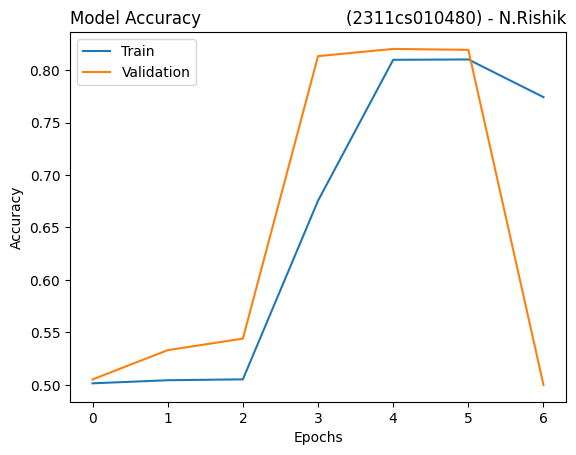

In [ ]:
# Step 9: Plot Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy',loc='left')
plt.title('(2311cs010480) - N.Rishik',loc='right')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

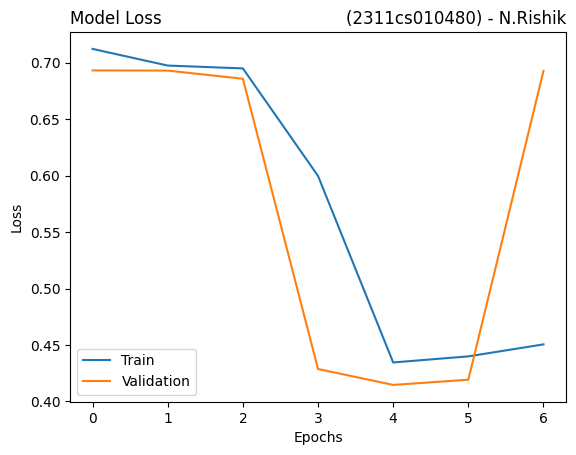

In [ ]:
# Step 10: Plot Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss',loc='left')
plt.title('(2311cs010480) - N.Rishik',loc='right')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [ ]:
# Step 11: Prediction Function
def predict_sentiment(review):
  # Convert text to sequence
  sequence = tokenizer.texts_to_sequences([review])
  # Pad sequence
  padded = pad_sequences(sequence, maxlen=max_length)
  # Predict
  prediction = model.predict(padded)[0][0]
  # Convert to label
  if prediction >= 0.5:
    sentiment = "Positive "
  else:
    sentiment = "Negative "
  print("\n Review:", review)
  print("Predicted Sentiment:", sentiment)
  print("Confidence Score:", prediction)

In [ ]:
# Step 12: Test with Samples
predict_sentiment("The cinematography was beautiful and the story was very touching.")
predict_sentiment("I fell asleep halfway through, the movie was extremely boring.")
predict_sentiment("The acting was decent but the plot was predictable.")
predict_sentiment("An incredible film with amazing performances and a powerful ending.")
predict_sentiment("The trailer looked good but the movie turned out to be disappointing.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 552ms/step

 Review: The cinematography was beautiful and the story was very touching.
Predicted Sentiment: Negative 
Confidence Score: 0.37451908
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

 Review: I fell asleep halfway through, the movie was extremely boring.
Predicted Sentiment: Negative 
Confidence Score: 0.016281463
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

 Review: The acting was decent but the plot was predictable.
Predicted Sentiment: Negative 
Confidence Score: 0.016163873
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step

 Review: An incredible film with amazing performances and a powerful ending.
Predicted Sentiment: Positive 
Confidence Score: 0.9611322
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

 Review: The trailer looked good but the movie turned out to be disappointing.
Predicted Sentiment: Negative 
Confidence Score: 0.017726742
